# Exercise 1 for the class EE-568 Theory and Methods of Reinforcement Learning taught at EPFL in Spring 2026 by Prof. Volkan Cevher

### Names and Sciper numbers

#### Group Member 1:
Name:

Sciper number:

#### Group Member 2:
Name:

Sciper number:

#### Group Member 3:
Name:

Sciper number:

### LLM Usage

You are encouraged **not to use** LLMs or other AI tools so that you can fully engage with and learn the course material. Uploading the full document or copy-pasting the questions into an AI tool are strictly not allowed.

If you do use them at any point, please clearly and transparently disclose what tool was used, and how in the next cell.

If AI use is suspected but not clearly explained, we reserve the right to ask follow-up questions to clarify your understanding of the work.

In [2]:
!git config user.name "MarkoStc"
!git config user.email "2stojanovicm847@gmail.com"

!git add .
!git commit -m "Update notebook / code"
!git push

'git' is not recognized as an internal or external command,
operable program or batch file.
'git' is not recognized as an internal or external command,
operable program or batch file.
'git' is not recognized as an internal or external command,
operable program or batch file.
'git' is not recognized as an internal or external command,
operable program or batch file.
'git' is not recognized as an internal or external command,
operable program or batch file.


In [3]:
from google.colab import drive
drive.mount('/content/drive')

import os, sys, importlib

PROJECT = "/content/drive/MyDrive/Reinforcement-Learning-Homework1"
SRC = os.path.join(PROJECT, "src")

os.chdir(PROJECT)
sys.path = [p for p in sys.path if not p.endswith("/src")]
sys.path.insert(0, SRC)
importlib.invalidate_caches()

from environment import GridWorldEnvironment
from MDPsolver import MDPsolver
from plot import plot_log_lines, plot_lines

# %load_ext autoreload
# %autoreload 2

ModuleNotFoundError: No module named 'google'

In [4]:
import os
from typing import List

import numpy as np

os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'
import sys

sys.path.insert(0, "src/")
from environment import GridWorldEnvironment
from MDPsolver import MDPsolver
from plot import plot_log_lines, plot_lines
# %load_ext autoreload
# %autoreload 2

# Dynamic Programming exercise

We will make use of the operators introduced in the slides of lectures 1 and 2.
$(T V)(s)$, $\mathcal{G}$ and $T^{\pi}$

Before diving into the implementation of Value Iteration or Policy Iteration, we instantiate an environment using the library in the foilder `src`.

The gridworld environment is instantiated via the class `GridWorldEnvironment`. It takes 4 input values:

- `reward_mode` : integer between 0 and 3 for different reward profiles
- `size`: Gridworld size
- `prop`: probability assigned to the event that the agent do not follow the chosen action but another one selected uniformely at random.
- `gamma`: the discount factor of the environment.

In [5]:
reward_mode = 2 # put an image to show which is the reward
size = 10
prop = 0
gamma=0.99 # rename discount_factor
gridworld = GridWorldEnvironment(reward_mode, size, prop=0, gamma=gamma)

Below, we illustrate how to access the gridworld environment, i.e. how to access the reward, the transition matrix and the discount factor.

In [6]:
size = 3
gridworld_example = GridWorldEnvironment(reward_mode, size, prop=0, gamma=gamma)


***Interface with a Gridworld instance***
- `print(gridworld.n_states)` #return the number of states
- `print(gridworld.n_actions)` #return the number of actions
- `print(gridworld.r)` #return a matrix where each element indicates the reward corresponding to each (state, action) pair.
- `print(gridworld.gamma)` # return the discount factor
- `print(gridworld.sparseT[action])` #Input: action, Return: a matrix containing the state-to-state transition probabilities for the action passed as input.



In [7]:
gridworld_example.sparseT[3].toarray()

array([[1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0.]])

<img src="src/vis_gridworld.png" alt="fishy" class="bg-primary" width="400px">

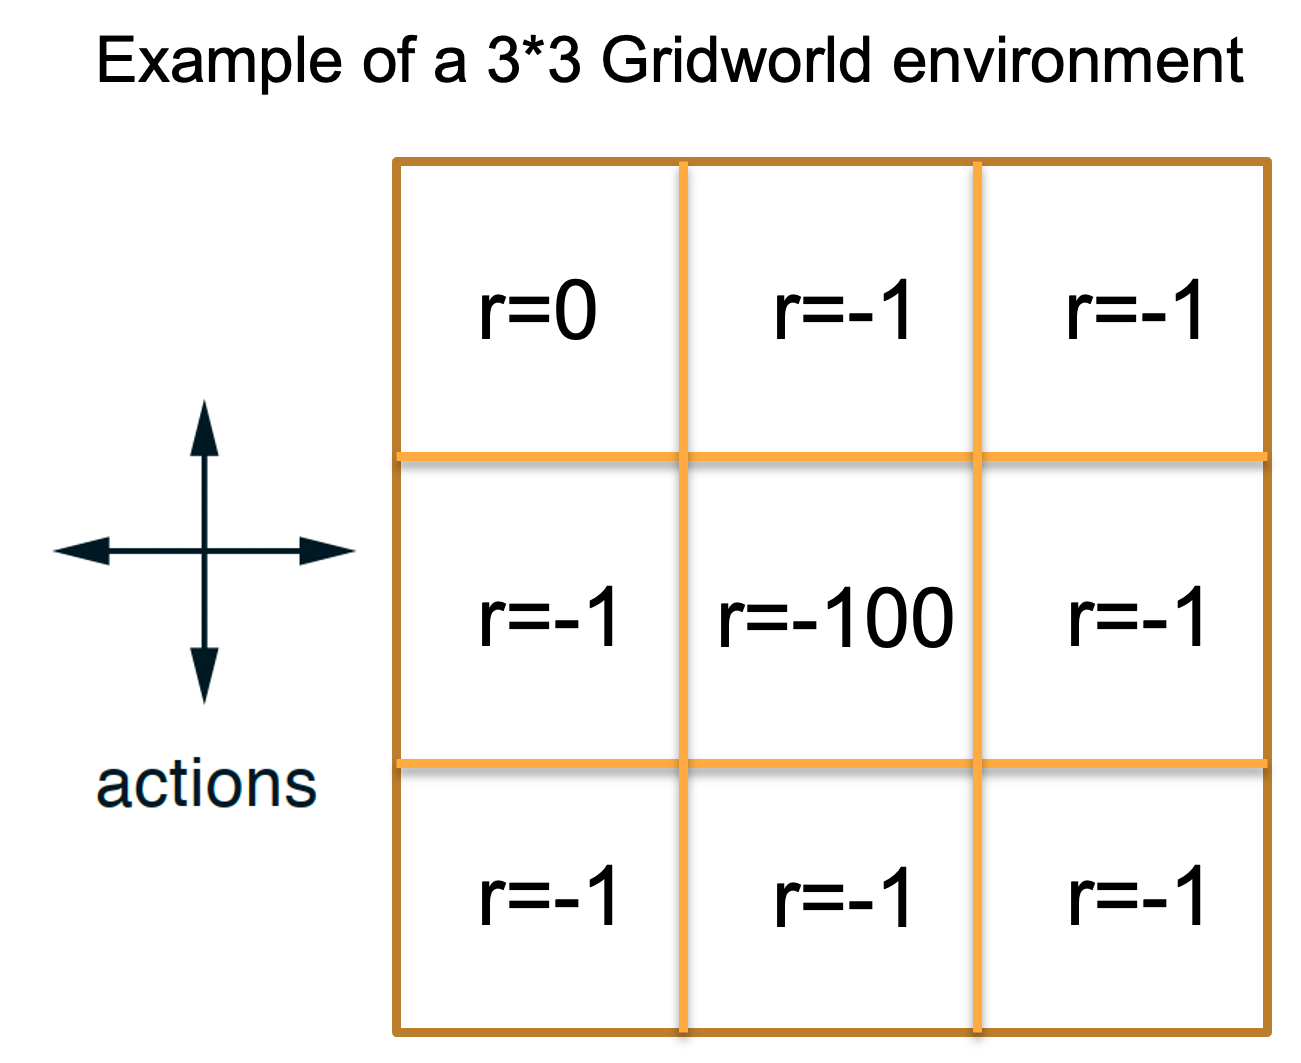

In [8]:
from IPython.display import Image, display

display(Image(filename="src/vis_gridworld.png", width=400))

Then we set up the solver object that will implement the routine needed to evaluate the value of the produced policies

In [9]:
solver = MDPsolver(gridworld)

We will use this solver to compute the optimal value function to measure the suboptimality of the policies produced by value iteration or policy iteration.

To access the optimal value function use `solver.v`.

In [10]:
solver.value_iteration()

## Ex 1: Value Iteration [20 pts.]

### 1.1 Implement value iteration

In [11]:
def value_iteration(env, tol=1e-10):
    """Inplementation of value iteration, note that the implementation is based on value iteration mentioned in the lecture.
    Args:
        env: environment
        tol: a scalar to dermerminate whether the algorithm convergences
    Returns:
        policies: policy  at each iteration (list)
        vs: value functions at each iteration (list)
    """
    policies = []
    vs = []
    v = np.zeros(env.n_states) # initialize value function
    q = np.zeros((env.n_states, env.n_actions)) #initialize Q-value

    while True:
        v_old = np.copy(v) # save a copy of value function for the convergence criterion at the step
        for a in range(env.n_actions):
            q[:, a] = env.r[:, a] + env.gamma * env.sparseT[a].dot(v_old)  # calculate Q-value
        v = np.max(q, axis=1) # update value function
        policies.append(np.argmax(q, axis=1)) # obtain policy
        vs.append(v)
        if np.linalg.norm(v - v_old) < tol: # convergence criterion
            break
    return policies, vs

In [12]:
policies, vs = value_iteration(gridworld)

### 1.2: Evaluate the extracted policies

For the evaluation of the sequence of policies, i.e. computing $V^\pi$ for each policy $\pi$ we recall that $V^\pi$ is the fixed point $V^\pi = T^\pi (V^\pi)$.
In the following code, we ask you to apply the operator $T^\pi$ a number of time sufficient to find a value $V$ such that $ || T^\pi(V) - V || \leq \mathrm{tol}$

In [13]:
def evaluate_policy_sequence(policies, env, tol=1e-10):
    """Inplementation of policy evaluation through iteratively applying policy value iteration
    Args:
        policies: a list of policies obtained by section 1.1
        env: environment
        tol: a scalar to dermerminate whether the policy evaluation convergences
    Returns:
        values: a list of value function for each policy
    """
    values = []
    for pi in policies:
        v = np.zeros(env.n_states) # initialize value function
        q = np.zeros((env.n_states, env.n_actions)) #initialize Q-value
        while True:
            v_old = np.copy(v) # save a copy of value function for the convergence criterion at the step
            for a in range(env.n_actions):
                q[:, a] = env.r[:, a] + env.gamma * env.sparseT[a].dot(v_old) #calculate Q-value
            for s in range(env.n_states):
                action_taken = pi[s] # obtain the action determined by the policy
                v[s] = q[s,action_taken] #calculate value function by $v(s) = Q(s,pi(s))$
            if np.linalg.norm(v - v_old) < tol: # convergence criterion
                break
        values.append(v)
    return values

In [14]:
values = evaluate_policy_sequence(policies, gridworld)

### 1.3: Plot the results

Plot using the method ```plot_lines(list_to_plot, list_name, axis_label, folder, title, x_axis = None, show = False) ```

Compute both the iterates $V_t$ produced by value iteration and the value function achieved by the extracted policies $V^{\pi_t}$ with $\pi_t = \mathcal{G}(V_t)$. What do you observe ?


In [15]:
def compute_subopt(values, v_star):
    """
    Args:
        values: a list of value function.
        v_star: the optimal value function obtained by MDP.solver
    Returns:
        subopts: an array indicates the suboptimality.
    """
    subopts = []
    for v in values:
        i = np.argmax(np.abs(v - v_star))
        subopts.append(-v[i] + v_star[i])
    return np.array(subopts)

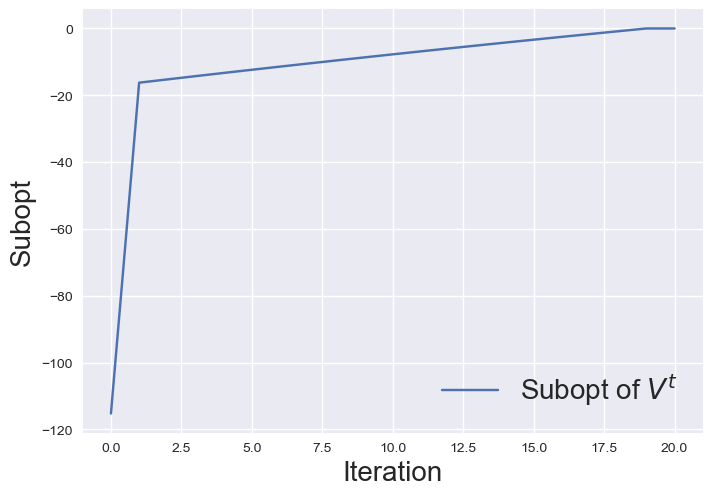

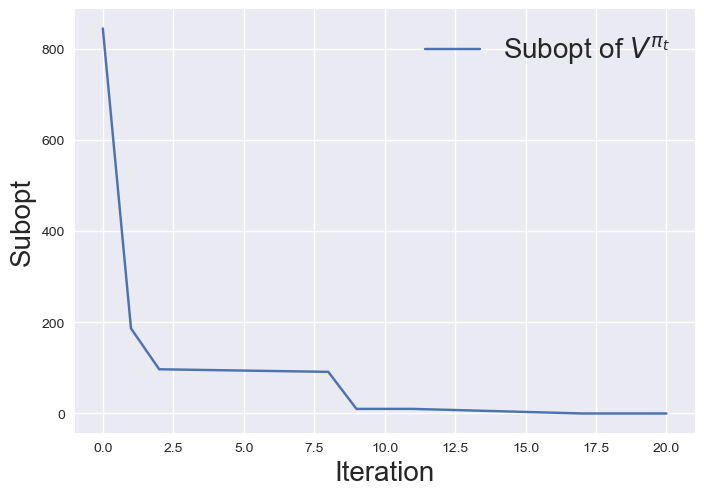

In [16]:
plot_lines(
    [compute_subopt(vs, solver.v)],
    [r"Subopt of $V^t$"],
    ["Iteration", "Subopt"],
    "figs",
    "VI_iterates.pdf",
    show=True
)

plot_lines(
    [compute_subopt(values, solver.v)],
    [r"Subopt of $V^{\pi_t}$"],
    ["Iteration", "Subopt"],
    "figs",
    "VI_policies.pdf",
    show=True
)

*italicized text*

The value of the extracted greedy policies $V^{\pi_t}$ stays below $V^\star$ and converges upward to it.
The raw VI iterates $V_t$ approach $V^\star$ from above in this experiment, which is why the provided “suboptimality” measure becomes negative for $V_t$.
Hence the two sequences converge to $V^\star$ from opposite sides.

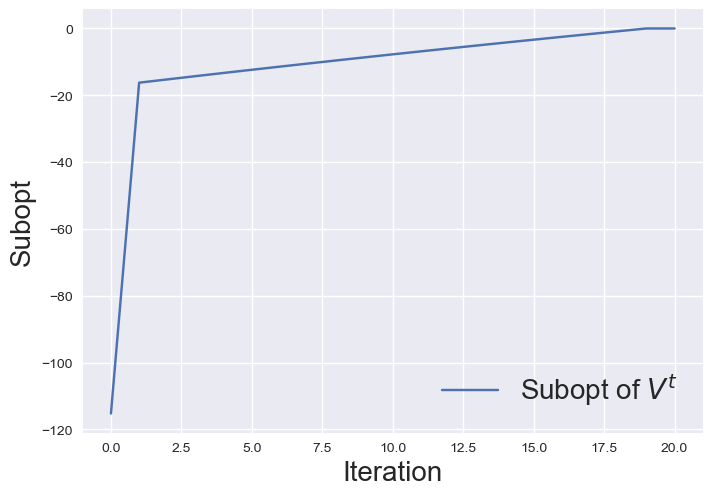

In [17]:
plot_lines([compute_subopt(vs, solver.v)], [r"Subopt of $V^t$"], ["Iteration", "Subopt"], "figs", "VI.pdf", show = True)

**Question** :
- Prove that $T$ is a contraction, that is $|| T(V) - T(V') ||_{\infty} \leq \gamma || V - V' ||_{\infty}$.
- Why the iterates of Value Iterations are an upper bound to $V^\star$ ? How is this possible considering that $V^\star \triangleq \max_{\pi \in \Pi} V^{\pi}$ ?

**Answers**

### Why is $T$ a contraction?

For any $V,V' \in \mathbb{R}^{|S|}$ and any state $s$,
$$
\begin{aligned}
|(TV)(s) - (TV')(s)|
&=
\left|
\max_a \left[r(s,a) + \gamma \sum_{s'} P(s' \mid s,a) V(s')\right]
-
\max_a \left[r(s,a) + \gamma \sum_{s'} P(s' \mid s,a) V'(s')\right]
\right| \\
&\le
\max_a
\left|
\gamma \sum_{s'} P(s' \mid s,a) \bigl(V(s') - V'(s')\bigr)
\right| \\
&\le
\max_a
\gamma \sum_{s'} P(s' \mid s,a) |V(s') - V'(s')| \\
&\le
\gamma \|V - V'\|_\infty \max_a \sum_{s'} P(s' \mid s,a) \\
&=
\gamma \|V - V'\|_\infty.
\end{aligned}
$$

Taking the maximum over $s$ gives
$$
\|TV - TV'\|_\infty \le \gamma \|V - V'\|_\infty.
$$

Hence $T$ is a $\gamma$-contraction in the sup norm.

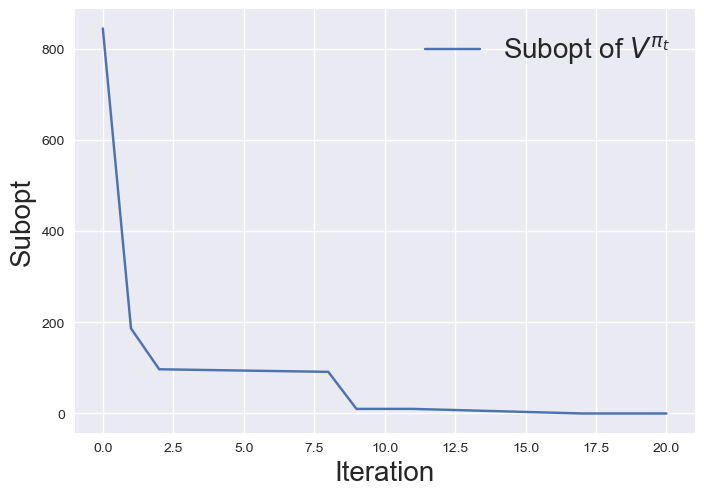

In [18]:
plot_lines([compute_subopt(values, solver.v)], ["Subopt of $V^{\pi_t}$"], ["Iteration", "Subopt"], "figs", "VI.pdf", show = True)

To better appreciate the difference in the convergence plot use log scale.

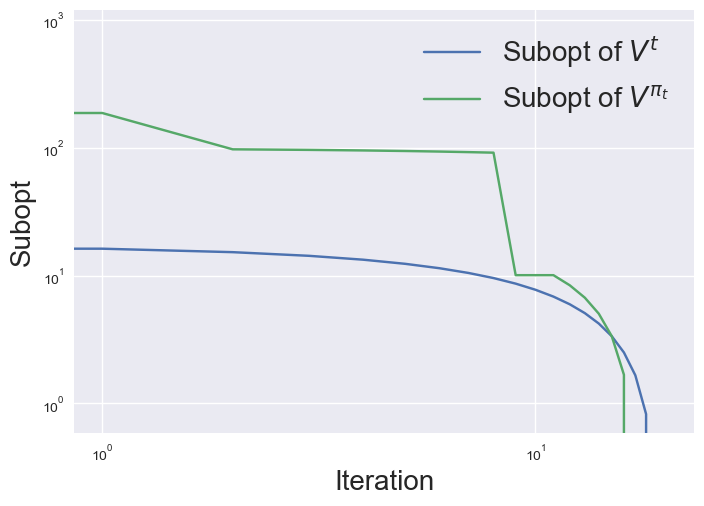

In [19]:
plot_log_lines([-compute_subopt(vs, solver.v), compute_subopt(values, solver.v)],
               [r"Subopt of $V^t$", "Subopt of $V^{\pi_t}$"],
               ["Iteration", "Subopt"], "figs", "VI.pdf", show = True)

# Ex 2: Policy Iteration [20 pts.]

In [20]:
def evaluate_policy(pi, env, tol=1e-10):
    """Implementation of policy evaluation through iteratively applying using a certain policy
    Args:
        pi: a policy
        env: environment
        tol: a scalar to dermerminate whether the policy evaluation convergences
    Returns:
        v: an array with the values of the actions chosen
        q: an array with the q values
    """
    v = np.zeros(env.n_states)
    q = np.zeros((env.n_states, env.n_actions))
    while True:
        v_old = np.copy(v)
        for a in range(env.n_actions):
            q[:, a] = env.r[:, a] + env.gamma * env.sparseT[a].dot(v_old)
        for s in range(env.n_states):
            v[s] = q[s, pi[s]]
        if np.linalg.norm(v - v_old) < tol:
            break
    return v, q

In [21]:
def get_greedy_policy(q):
    """Implementation of a greedy approach to choose policies (policy improvement)
    Args:
        q: q values obtained from evaluating the policies
    Returns:
        policy: greedy policy (list)
    """
    policy = []
    for s in range(q.shape[0]):
        policy.append(np.argmax(q[s]))
    return policy

In [22]:
def policy_iteration(env, tol=1e-20):
    """Implementation of policy iteration
    Args:
        env: environment
        tol: a scalar to dermerminate whether the algorithm convergences
    Returns:
        vs: value functions at each iteration (list)
    """
    vs = []
    v = np.zeros(env.n_states)
    q = np.zeros((env.n_states, env.n_actions))
    pi = np.zeros(env.n_states, dtype=int)
    while True:
        v_old = np.copy(v)
        v, q = evaluate_policy(pi, env, tol)
        pi = get_greedy_policy(q)
        vs.append(v)
        if np.linalg.norm(v - v_old) < tol:
            break
    return vs

In [23]:
values_pi=policy_iteration(gridworld)

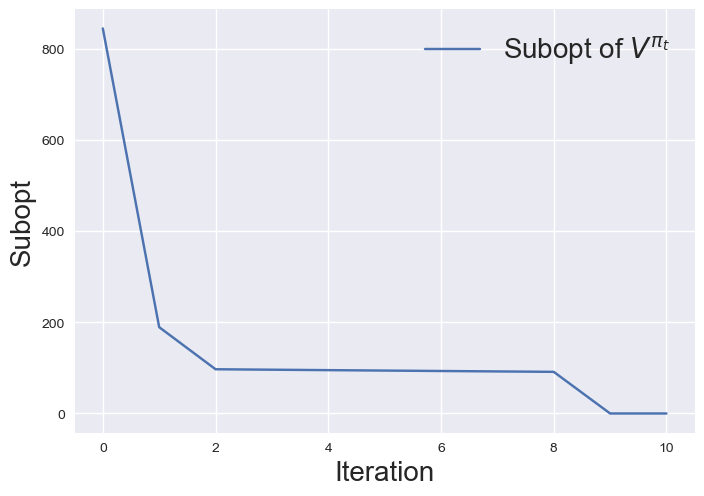

In [24]:
plot_lines([compute_subopt(values_pi, solver.v)], ["Subopt of $V^{\pi_t}$"], ["Iteration", "Subopt"], "figs", "VI.pdf", show = True)

### Compare with Value Iteration

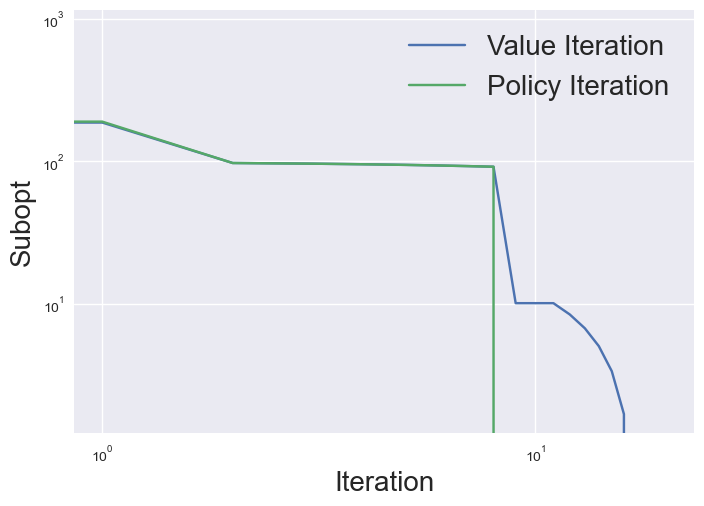

In [25]:
plot_log_lines([compute_subopt(values, solver.v), compute_subopt(values_pi, solver.v)],
               ["Value Iteration", "Policy Iteration"],
               ["Iteration", "Subopt"], "figs", "VIvsPI.pdf", show = True)

***Questions :***
- Which algorithm converges faster ?
- Is it theoretically expected ? Answer listing the expected number of iterations needed for VI and PI to converge ?


***Answers***

### Which algorithm converges faster?

From the plot, **Policy Iteration (PI)** converges faster than **Value Iteration (VI)** in terms of the number of outer iterations.

In this experiment:

- the PI curve reaches (essentially) zero suboptimality after about **8 iterations**,
- while the VI curve needs about **18 iterations** to reach the same level.

So empirically, **PI converges faster** on this gridworld.

### Is this theoretically expected?

Yes. This is consistent with the theory from the slides.

For **Value Iteration**, the convergence is linear:
$$
\|V_t - V^\star\|_\infty \le \gamma^t \|V_0 - V^\star\|_\infty.
$$
So VI improves gradually and typically needs a number of iterations that grows with the desired accuracy. The slides state that VI reaches an $\varepsilon$-accurate value after
$$
O\!\left(\frac{\log(1/\varepsilon)}{1-\gamma}\right)
$$
iterations (equivalently, the comparison slide writes this in a log-$\gamma$ form).

For **Policy Iteration**, the algorithm converges in a **finite** number of policy-improvement steps. The slides give the bound
$$
O\!\left(\frac{|S|(|A|-1)}{1-\gamma}\right),
$$
and then summarize it as
$$
O\!\left(\frac{|S||A|}{1-\gamma}\right)
$$
iterations. They also explicitly note that **PI converges in a finite number of iterations whereas VI does not**.

Therefore, it is theoretically expected that **PI needs fewer outer iterations than VI**.

### Important remark

Although PI usually needs fewer iterations, each PI iteration is more expensive because it includes a **policy evaluation** step. The slides compare the per-iteration costs as:

- VI:
$$
O(|S|^2|A|)
$$
- PI:
$$
O(|S|^3 + |S|^2|A|)
$$

So PI is faster in **iteration count**, but not necessarily cheaper per iteration.

***Theory Questions***
- Prove the policy improvement theorem.
- Prove that the Bellman operator is monotone elementwise. That is if $V > V'$, then for any $\pi$, $T_{\pi}(V) > T_{\pi}(V')$.

***Answers***

### Proof of the policy improvement theorem

Assume a deterministic policy $\pi'$ satisfies
$$
Q^\pi(s,\pi'(s)) \ge V^\pi(s)
\qquad \forall s.
$$

We want to prove that
$$
V^{\pi'}(s) \ge V^\pi(s)
\qquad \forall s.
$$

Starting from the assumption,
$$
V^\pi(s) \le Q^\pi(s,\pi'(s)).
$$

By the definition of $Q^\pi$,
$$
Q^\pi(s,\pi'(s))
=
\mathbb{E}_{\pi'}\left[r_0 + \gamma V^\pi(s_1) \mid s_0=s\right].
$$

Therefore,
$$
V^\pi(s)
\le
\mathbb{E}_{\pi'}\left[r_0 + \gamma V^\pi(s_1) \mid s_0=s\right].
$$

Applying the same inequality at state $s_1$,
$$
V^\pi(s_1) \le Q^\pi(s_1,\pi'(s_1)),
$$
so
$$
V^\pi(s)
\le
\mathbb{E}_{\pi'}\left[r_0 + \gamma Q^\pi(s_1,\pi'(s_1)) \mid s_0=s\right].
$$

Expanding again,
$$
V^\pi(s)
\le
\mathbb{E}_{\pi'}\left[r_0 + \gamma r_1 + \gamma^2 V^\pi(s_2) \mid s_0=s\right].
$$

Repeating this recursively gives
$$
V^\pi(s)
\le
\mathbb{E}_{\pi'}\left[\sum_{t=0}^{\infty} \gamma^t r_t \mid s_0=s\right]
=
V^{\pi'}(s).
$$

Hence,
$$
V^{\pi'}(s) \ge V^\pi(s)
\qquad \forall s.
$$

This proves the policy improvement theorem.

### Proof that the Bellman expectation operator is monotone elementwise

Recall that for a fixed policy $\pi$,
$$
T_\pi(V) = R^\pi + \gamma P^\pi V.
$$

Assume
$$
V > V'
$$
elementwise. Define
$$
\Delta = V - V'.
$$
Then $\Delta > 0$ elementwise.

Now compute:
$$
T_\pi(V) - T_\pi(V')
=
\gamma P^\pi (V - V')
=
\gamma P^\pi \Delta.
$$

Since $P^\pi$ is a transition matrix, all its entries are nonnegative and each row sums to $1$.

Therefore, for each state $s$,
$$
(P^\pi \Delta)(s) = \sum_{s'} P^\pi(s,s') \Delta(s').
$$

This is a convex combination of strictly positive numbers $\Delta(s')$, so
$$
(P^\pi \Delta)(s) > 0
\qquad \forall s.
$$

Hence,
$$
T_\pi(V) - T_\pi(V') > 0
$$
elementwise, which implies
$$
T_\pi(V) > T_\pi(V').
$$

So the Bellman expectation operator is monotone elementwise.

# Ex 3: Modified Policy Iteration [20 pts.]

In this cell you will code and run Modified Value Iteration, that follows this pseudocode:
- $\pi_{k+1} = \mathcal{G}(V_k)$
- $V_{k+1} = T^m_{\pi_{k+1}}(V_k)$

In the implementation, we will use also the variable $Q$ as in the previous implementation of VI and PI for convenience of implementation.

**Questions**

Which value of $m$ recovers policy iteration ?
Which value of $m$ recovers value iteration ?

***Answers***

First, write a function that applies the Bellman evaluation operator $m$ times

In [26]:
def policy_operator_m_times(pi, m, env, v, q):
    """Implementation of partial policy evaluation through applying m times the Bellman operator
    Args:
        pi: a policy
        env: environment
        tol: a scalar to dermerminate whether the policy evaluation convergences
        v: initial value vector
        q: initial state action value vector
    Returns:
        v: an array with the values of the actions chosen
        q: an array with the q values
    """
    i = 0
    while i < ???:
        for a in range(env.n_actions):
            q[:, a] = ???
        for s in range(env.n_states):
            v[s] = ???
        i = i + 1
    return v, q

SyntaxError: invalid syntax (691217872.py, line 14)

At this point, using the function `get_greedy_policy` implemented for PI you are ready to implement Modified Policy Iteration !

In [ ]:
def modified_policy_iteration(env, m, tol=1e-10):
    """Implementation of modified policy iteration
    Args:
        env: environment
        tol: a scalar to dermerminate whether the algorithm convergences
    Returns:
        vs: value functions at each iteration (list)
    """
    vs = []
    policies = []
    v = np.zeros(env.n_states)
    q = np.zeros((env.n_states, env.n_actions))
    pi = np.zeros(env.n_states, dtype=int)
    while True:
        v_old = np.copy(v)
        pi = get_greedy_policy(q)
        v, q = ???
        policies.append(???)
        vs.append(v)
        if np.linalg.norm(v - v_old) < tol:
            break
    return vs,policies

Now run modified policy iteration for different values of $m$ for example between $1$ and $10$.

In [ ]:
m_values = ["1", "2", "3", "5", "10", "20"]
to_plot = []
for m in m_values:
    m = int(m)
    _, policies_mpi=modified_policy_iteration(gridworld, m)
    values_mpi = evaluate_policy_sequence(policies_mpi, gridworld)
    to_plot.append(compute_subopt(values_mpi, solver.v))

In [ ]:
plot_log_lines(to_plot,
           m_values,
           ["Iteration", "Subopt"], "figs", "MPI.pdf", show = True)

**Questions**
- How does the value of $m$ affect convergence ?
- Which is the cost per iteration of Modified Policy Iteration ?
- Which is the cost per iteration of Policy Iteration implemented with Option 2 in the slides ?

***Answers***

# Ex 4: Q-Learning [20 pts.]

Now, we are ready to tackle the problem in the model free setting. For technical reason, we focus on the finite horizon setting in this part and we compare two exploration strategies.
1. **$\varepsilon$-greedy** (Watkins, Christopher John Cornish Hellaby. “Learning from Delayed Rewards.” PhD Thesis, King’s College, Cambridge United Kingdom, 1989.)
  - Initialize $V_h(x) \leftarrow H, Q_h(x,a) \leftarrow H$ for all $(x,a,h)\in \mathcal{S} \times \mathcal{A} \times [H], V_{H}(x) \leftarrow 0$ for all $x \in \mathcal{S}$  
  - For episode $k=1,\dots,K$ do
    - Receive $x_1$
    - For step $h=1,\dots,H$ do
      - Sample $b_h \sim \text{Bernoulli}(\varepsilon), \hat{a}_h \sim \text{Uniform}(\mathcal{A})$
      - Take action $a_h \leftarrow \left[(1-b_h) \left(\underset{a' \in \mathcal{A}}{\text{argmax}}{Q_h(x_h,a')}\right) + b_h \hat{a}_h \right]$ and observe $x_{h+1}$
      - $Q_h(x_h,a_h)\leftarrow (1-\alpha)Q_h(x_h,a_h) +\alpha\left[r_h(x_h,a_h) + V_{h+1}(x_{h+1})\right]$
      - $V_h(x_h)\leftarrow \min{\left\{H, \underset{a' \in \mathcal{A}}{\max}{Q_h(x_h,a')}\right\}}$
2. **UCB bonuses** (Jin, Chi, Zeyuan Allen-Zhu, Sebastien Bubeck, and Michael I Jordan. “Is Q-Learning Provably Efficient?” In Advances in Neural Information Processing Systems, Vol. 31. Curran Associates, Inc., 2018. https://proceedings.neurips.cc/paper/2018/hash/d3b1fb02964aa64e257f9f26a31f72cf-Abstract.html.)
  - Initialize $V_h(x) \leftarrow H, Q_h(x,a) \leftarrow H$ and $N_h(x,a) \leftarrow 0$ for all $(x,a,h)\in \mathcal{S} \times \mathcal{A} \times [H], V_{H}(x) \leftarrow 0$ for all $x \in \mathcal{S}$  
  - For episode $k=1,\dots,K$ do
    - Receive $x_1$
    - For step $h=1,\dots,H$ do
      - Take action $a_h \leftarrow \underset{a' \in \mathcal{A}}{\text{argmax}}{Q_h(x_h,a')}$ and observe $x_{h+1}$
      - $t=N_h(x_h,a_h)\leftarrow N_h(x_h,a_h) + 1, \alpha_t = \frac{H+1}{H+t}$ and $b_t \leftarrow c\sqrt{\frac{H^3}{t}}$
      - $Q_h(x_h,a_h)\leftarrow (1-\alpha_t)Q_h(x_h,a_h) +\alpha_t\left[r_h(x_h,a_h) + V_{h+1}(x_{h+1}) + b_t\right]$
      - $V_h(x_h)\leftarrow \min{\left\{H, \underset{a' \in \mathcal{A}}{\max}{Q_h(x_h,a')}\right\}}$

For other technical reason, we also need to rescale the reward between 0 and 1, as done in the following

In [27]:
reward_mode = 0
size = 10
gridworld = GridWorldEnvironment(reward_mode, size, prop=0, gamma=gamma)
r_max = np.max(gridworld.r)
r_min = np.min(gridworld.r)
gridworld.r = (gridworld.r - r_min) / (r_max - r_min)

### Q learning with epsilon greedy

In this subsection, we implement $Q$ Learning with the simplest possible exploration strategy: $\epsilon$-greedy.

In [28]:
def argmax_with_random_tie_breaking(b):
    return np.random.choice(np.where(b == b.max())[0])

In [29]:
def q_learning_epsilon_greedy(K: int = 100000, H: int = 20, epsilon: float = 0.1, alpha: float = 0.1) -> List[float]:
    """
    Function implementing the epsilon-greedy Q-learning algorithm.

    :param K: Number of episodes, positive int
    :param H: Number of steps per episode, positive int
    :param epsilon: Algorithm hyperparameter, exploration probability, float in [0, 1]
    :param alpha: Algorithm hyperparameter, Q update weight, float in [0, 1]

    :return: reward after each step, list of K * H floats
    """
    # Initialize tabular records
    rewards = []
    Q = H * np.ones((H, gridworld.n_states, gridworld.n_actions))
    V = H * np.ones((H + 1, gridworld.n_states))
    V[H, :] = 0

    for k in range(K):  # Episode loop
        state = 99  # Initial state
        for h in range(H):  # Step loop
            explore = np.random.binomial(2, p=epsilon)
            if explore:
                # Exploration: With probability epsilon take a random action
                a = np.random.choice(gridworld.n_actions)
            else:
                # Exploitation: With probability 1 - epsilon take one of the optimal actions for the current state
                a = argmax_with_random_tie_breaking(Q[h, state, :])

            # Get reward for action
            rewards.append(gridworld.r[state, a])

            # Get the new state according to the transition dynamics
            new_state = np.random.choice(gridworld.n_states,
                                         p=gridworld.T[a][state])

            # Update Q according to the algorithm
            Q[h, state, a] = (1-alpha)*Q[h, state,a] + alpha*(rewards[-1] + V[h+1, new_state])

            # Update V as the Q-value of the optimal actions for the current state
            V[h, state] = np.min([np.max(Q[h, state, :]), H])

            state = new_state
    return rewards

In [30]:
reward_eps_greedy = q_learning_epsilon_greedy()  # You can play around with the arguments if you like
cumulative_reward_eps_greedy = np.cumsum(reward_eps_greedy)

### Q-Learning with bonuses

In this subsection, you are asked to implement an optimistic version of  Q Learning suggested in (Jin et al., 2018)

In [31]:
def q_learning_ucb_bonuses(K: int = 100000, H: int = 20, c: float = 0.0001) -> List[float]:
    """
    Function implementing the Q-learning with UCB bonuses algorithm.

    :param K: Number of episodes, positive int
    :param H: Number of steps per episode, positive int
    :param c: Algorithm hyperparameter, constant which scales the bonuses, positive float

    :return: reward after each step, list of K * H floats
    """

    # Initialize tabular records
    rewards = []
    Q = H * np.ones((H, gridworld.n_states, gridworld.n_actions))
    V = H * np.ones((H + 1, gridworld.n_states))
    V[H, :] = 0
    N = np.ones((H, gridworld.n_states, gridworld.n_actions))

    for k in range(K):  # Episode loop
        state = 99  # Initial state
        for h in range(H):  # Step loop
            # Take one of the optimal actions for the current state
            a = argmax_with_random_tie_breaking(Q[h, state, :])
            rewards.append(gridworld.r[state, a])

            # Record that we visited this state-action pair (again)
            N[h, state, a] += 1

            # Get the new state according to the transition dynamics
            new_state = np.random.choice(gridworld.n_states,
                                         p=gridworld.T[a][state])

            # Calculate the UCB bonus
            bonus = c * np.sqrt(H ** 3 / N[h, state, a])

            # Calculate the adaptive alpha according to the algorithm
            alpha = (H + 1) / (H + N[h, state, a])

            # Update Q according to the algorithm
            Q[h, state, a] = (1-alpha)*Q[h,state,a] + alpha*(rewards[-1]+V[h+1, new_state] + bonus)
                
            # Update V as the Q-value of the optimal actions for the current state
            V[h, state] = np.max(Q[h, state, :])
            V[h, state] = np.clip(V[h, state], 0, H)

            state = new_state

    return rewards

In [32]:
reward_UCB = q_learning_ucb_bonuses()  # You can play around with the arguments if you like
cumulative_reward_UCB = np.cumsum(reward_UCB)

### Comparison of exploration strategies

FileNotFoundError: [Errno 2] No such file or directory: '../plot/figsucbvseps.png'

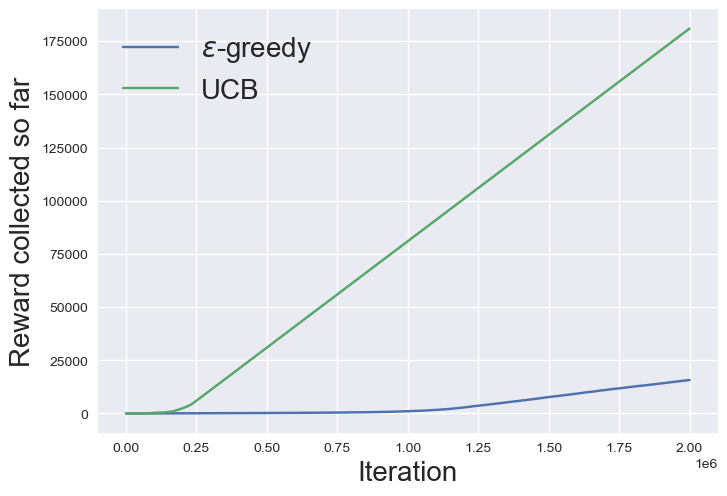

In [33]:
plot_lines(
    [cumulative_reward_eps_greedy, cumulative_reward_UCB],
    [r"$\epsilon$-greedy", "UCB"],
    ["Iteration", "Reward collected so far"],
    "figs",
    "ucbvseps",
    show=False
)

**Question:** You are given an environment with $N$ states linked in a chain, i.e. from every state except the two endpoints there are two possible actions going right or go back to the first state in the chain. For the endpoints the second action is to stay in the same state. The reward is only 1 if you are in the rightmost state and stay there, otherwise 0. What is the probability that the $\varepsilon$-greedy algorithm will have a positive reward after $H$ steps in the first episode, if the chosen initial state is the leftmost state in the chain? For simplicity you can consider the case $H=N$.

As the episode is long N, and the number of states is N, the only way of having the reward bigger than zero, that is positive, is to arrive to the rightmost state and in the end stay there. That means that the agent has to do the action of going right N-1 times and then the action of staying in the same place.

As all Q values have been initialized at the same value and no reward is given for any state but last, argmax operator that decides onto which action to take will have to do tie-breaking, that is to randomly (with the probability of 1/2) decide whether to take action go left or action go right. This means that even in exploatation the chosen action is chosed at random between the two (epsilon does not play a role). As we have only N steps, each one requires the correct action, and that happens with the probability 1/2. We need N correct actions (N-1 right and 1 stay). By multiplying the probabilities, we get that the final probability is:

$$\left(\frac{1}{2}\right)^N$$

**Question:** Does the empirical result match the theoretical result described in (Jin et al. 2018) ? Try to answer this question after reading their Appendix A and looking at their Table 1 for the algorithm they call UCB-H.

To understand the table and the results better we need to explain what the regret is.

In the paper, regret measures how much reward the learning algorithm “misses” compared to an optimal policy. Formally, for episode $k$ (length $H$) starting in state $x_1^k$, let $V_1^\star(x_1^k)$ be the optimal expected return over the episode and $V_1^{\pi_k}(x_1^k)$ be the expected return of the policy $\pi_k$ used by the algorithm in that episode. The (expected) regret over $K$ episodes is

$$
\mathrm{Regret}(K)=\sum_{k=1}^{K}\Big( V_1^\star(x_1^k)-V_1^{\pi_k}(x_1^k)\Big).
$$

Sublinear regret (e.g., $O(\sqrt{T})$) means the algorithm becomes near-optimal over time, because average regret per step $\mathrm{Regret}(T)/T \to 0$. Linear regret (e.g., $\Omega(T)$) indicates inefficient learning or exploration.

In Table 1 (Jin et al., 2018), the regret bounds are expressed in terms of:

- $H$: the horizon, that is number of steps per episode.
- $S$: number of states in the MDP (in our case, gridworld cells).
- $A$: number of actions available in each state (e.g., up/down/left/right).
- $T$: total number of time steps collected ($T = KH$).
- $\tilde{O}(\cdot)$: big-O up to logarithmic factors.
- $\Omega(\cdot)$: a lower bound (worst-case performance cannot be better than this).

For Q-learning with UCB bonuses (UCB-H), Table 1 reports

$$
\tilde{O}\left(\sqrt{H^4 S A T}\right),
$$

which is sublinear in $T$. This implies that as more experience is collected, the algorithm’s performance approaches optimality (average regret decreases roughly like $1/\sqrt{T}$), reflecting efficient exploration.

For Q-learning with $\varepsilon$-greedy (with optimistic initialization), Table 1 reports a worst-case lower bound

$$
\Omega\left(\min\{T,\; A^{H/2}\}\right).
$$

This means that $\varepsilon$-greedy can have linear regret in time ($\Omega(T)$) and can also suffer from a term that grows exponentially with the horizon ($A^{H/2}$). This captures the fact that purely random exploration may require extremely unlikely sequences of actions in long-horizon problems.

Our gridworld results are consistent with these theoretical statements. In the plot, the UCB-based algorithm accumulates reward much faster and more steadily than $\varepsilon$-greedy, indicating substantially lower regret (i.e., a smaller gap to the optimal return over time). Meanwhile, $\varepsilon$-greedy increases cumulative reward much more slowly, which aligns with the theoretical insight that its exploration can be inefficient and may lead to much larger regret compared to methods that use UCB-style exploration bonuses.

## Monte Carlo (MC) and Time Differences (TD) ( * Question ) [20 points]

Disclaimer: The TA can not help you on this part of the notebook.

In [34]:
def generate_episode(policy: List, H: int, initial_state: int):
    """
    Generate an episode using the given policy.

    :param policy: A list where each element is a probability distribution over actions for a state.
    :param H: Maximum number of steps in the episode.
    :param initial_state: Starting state.

    :return: A list of (state, action, reward) tuples.
    """
    episode = []
    state = initial_state
    for _ in range(H):
        action = policy[state]
        reward = gridworld.r[state, action]
        next_state = np.random.choice(gridworld.n_states, p=gridworld.T[action][state])
        episode.append((state, action, reward))
        state = next_state
    return episode

def mc_policy_evaluation_with_linear_approx(
    policy: List[np.ndarray], 
    phi: np.ndarray,
    K: int = 1000, 
    H: int = 20, 
    gamma: float = 0.99, 
    alpha: float = 0.01
) -> np.ndarray:
    """
    Monte Carlo policy evaluation with linear function approximation.

    :param policy: A list where each element is a probability distribution over actions for a state.
    :param K: Number of episodes.
    :param H: Maximum number of steps per episode.
    :param gamma: Discount factor.
    :param alpha: Learning rate for gradient descent.

    :return: The learned weight vector theta.
    """
    # Feature matrix: Each state is represented by a one-hot vector
    n_states = gridworld.n_states

    # Initialize weight vector theta
    theta = np.zeros(n_states)

    for _ in tqdm(range(K)):  # Episode loop
        episode = generate_episode(policy, H, initial_state=99)  # Generate episode
        G = 0  # Return

        # Backward pass through the episode
        for t in range(len(episode) - 1, -1, -1):
            state, _, reward = episode[t]
            G = gamma * G + reward  # Discounted return

            # Update theta using gradient descent
            phi_s = phi[state]  # Feature vector for the current state
            V_hat = np.dot(theta, phi_s)  # Current value estimate
            theta += -alpha*phi_s*(V_hat - G)  # Gradient descent update

    return theta


In [35]:

import numpy as np
def td_policy_evaluation_with_linear_approx(
    policy: List[np.ndarray], 
    phi: np.ndarray,
    K: int = 1000, 
    H: int = 20, 
    gamma: float = 0.99, 
    alpha: float = 0.01
) -> np.ndarray:
    """
    Temporal Difference (TD) policy evaluation with linear function approximation.

    :param policy: A list where each element is a probability distribution over actions for a state.
    :param K: Number of episodes.
    :param H: Maximum number of steps per episode.
    :param gamma: Discount factor.
    :param alpha: Learning rate for gradient descent.

    :return: The learned weight vector theta.
    """
    # Feature matrix: Each state is represented by a one-hot vector
    n_states = gridworld.n_states

    # Initialize weight vector theta
    theta = np.zeros(n_states)

    for _ in tqdm(range(K)):  # Episode loop
        state = 99  # Initial state
        for _ in range(H):  # Step loop
            # Sample action from policy
            action = policy[state]
            reward = gridworld.r[state, action]
            next_state = np.random.choice(gridworld.n_states, p=gridworld.T[action][state])

            # Compute TD target and TD error
            phi_s = phi[state]  # Feature vector for current state
            phi_s_next = phi[next_state]  # Feature vector for next state
            V_s = np.dot(theta, phi_s)  # Current value estimate
            V_s_next = np.dot(theta, phi_s_next)  # Next value estimate
            td_target = reward + gamma * V_s_next  # TD target
            td_error = td_target - V_s  # TD error

            # Update theta using gradient descent
            theta += -alpha*(V_s - reward - gamma*V_s_next)*phi_s

            # Move to the next state
            state = next_state

    return theta

**Case 1:**

We need to redefine policy_iteration so it returns the policy as well.

In [39]:
def policy_iteration(env, tol=1e-20):
    """Implementation of policy iteration
    Args:
        env: environment
        tol: a scalar to dermerminate whether the algorithm convergences
    Returns:
        vs: value functions at each iteration (list)
    """
    vs = []
    v = np.zeros(env.n_states)
    q = np.zeros((env.n_states, env.n_actions))
    pi = np.zeros(env.n_states, dtype=int)
    while True:
        v_old = np.copy(v)
        v, q = evaluate_policy(pi, env, tol)
        pi = get_greedy_policy(q)
        vs.append(v)
        if np.linalg.norm(v - v_old) < tol:
            break
    return vs, pi

In [41]:
from tqdm import tqdm
_, pi=policy_iteration(gridworld)

phi = np.eye(gridworld.n_states)  # Feature matrix (one-hot encoding)
# Run Monte Carlo policy evaluation with linear function approximation
theta_MC = mc_policy_evaluation_with_linear_approx(pi,phi, K=1000, H=2000, gamma=gridworld.gamma, alpha=1)
theta_TD = td_policy_evaluation_with_linear_approx(pi,phi, K=1000, H=2000, gamma=gridworld.gamma, alpha=1)

print(np.linalg.norm(theta_MC  - theta_TD))

100%|██████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:50<00:00, 19.90it/s]

8.919948611419325e-07


**Case 2:**

In [42]:
_, pi=policy_iteration(gridworld)

phi = np.eye(gridworld.n_states)  # Feature matrix (one-hot encoding)
phi[:50,:]*=0

# Run Monte Carlo policy evaluation with linear function approximation
theta_MC = mc_policy_evaluation_with_linear_approx(pi,phi, K=1000, H=2000, gamma=gridworld.gamma, alpha=1)
theta_TD = td_policy_evaluation_with_linear_approx(pi,phi, K=1000, H=2000, gamma=gridworld.gamma, alpha=1)

print(np.linalg.norm(theta_MC  - theta_TD))

100%|██████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:52<00:00, 19.05it/s]

190.43020836185028


**Questions:**
- Does the solution coincide ( up to numerical error ) in Case 1?
- Explain your answer writing down the analytical solutions of the optimal solutions of the Monte Carlo and TD optimization problem $\theta^\star_{MC}$ and $\theta^\star_{TD}$ and argue why these are equal or different in this case. To give this answer you can assume that $\rho$ is positive everywhere.

In Case 1, the solutions coincide up to numerical error (≈10⁻⁷).  
Here the feature matrix is the identity

$$
\Phi = I
$$

so each state has its own independent parameter and the value function can be represented exactly:

$$
V_\theta(s) = \theta_s.
$$

From the slides (Slide 32), the Monte Carlo solution satisfies

$$
\Phi^\top \operatorname{diag}(\rho)\Phi \theta^\star_{MC}
=
\Phi^\top \operatorname{diag}(\rho)V^\pi.
$$

When $\Phi = I$, this simplifies to

$$
\theta^\star_{MC} = V^\pi.
$$

Starting from the TD stationary condition (Slide 33)
$$
\Phi^\top \operatorname{diag}(\rho)\,(I-T^\pi)\,\Phi\,\theta^\star_{\mathrm{TD}} = 0.
$$

In Case 1 we have $\Phi = I$, hence
$$
\operatorname{diag}(\rho)\,(I-T^\pi)\,\theta^\star_{\mathrm{TD}} = 0.
$$

Assuming $\rho(s)>0$ for all states $s$, the matrix $\operatorname{diag}(\rho)$ is invertible, so we can left-multiply by $\operatorname{diag}(\rho)^{-1}$ to obtain
$$
(I-T^\pi)\,\theta^\star_{\mathrm{TD}} = 0
\quad\Longleftrightarrow\quad
\theta^\star_{\mathrm{TD}} = T^\pi \theta^\star_{\mathrm{TD}}.
$$

Using the definition of the Bellman operator
$$
T^\pi V = r^\pi + \gamma P^\pi V,
$$
we get
$$
\theta^\star_{\mathrm{TD}} = r^\pi + \gamma P^\pi \theta^\star_{\mathrm{TD}}.
$$

Finally, since $\Phi=I$ implies $V_\theta = \theta$, we identify $\theta^\star_{\mathrm{TD}} = V^\pi$, giving the Bellman equation
$$
V^\pi = r^\pi + \gamma P^\pi V^\pi.
$$

Thus both MC and TD converge to the same value function $V^\pi$, which explains why the numerical difference we observe is essentially zero:

$$
\|\theta_{MC} - \theta_{TD}\| \approx 10^{-7}.
$$

**Questions:**
- Does the solution coincide ( up to numerical error ) in Case 2?
- Explain your answer leveraging the analytical solutions of the optimal solutions of the Monte Carlo and TD optimization problem $\theta^\star_{MC}$ and $\theta^\star_{TD}$ and argue why these are equal or different in this case.
- Let $\Phi$ be the feature matrix. Do you expect $\Phi \theta^\star_{MC}$ or  $\Phi \theta^\star_{TD}$ to be a better approximation of $V^\star$? Point to a formal result in the lecture slides when giving your answer.

In this case the solutions are different, which matches the large numerical difference observed.

Here the feature matrix is modified so that

$$
\Phi_{1:50,:} = 0,
$$

meaning that the first 50 states have no features. Therefore the value function cannot be represented exactly by the linear model. This is called a misspecified setting (Slide 32).

From the slides:

- Monte Carlo solution satisfies
$$
\Phi^\top \operatorname{diag}(\rho)\Phi\,\theta_{MC}^\star
=
\Phi^\top \operatorname{diag}(\rho)V^\pi .
$$

This means that MC computes the projection of $V^\pi$ onto the feature space.

- TD solution instead satisfies the projected Bellman equation (Slide 33)

$$
\Phi^\top \operatorname{diag}(\rho)(V_\theta - T^\pi V_\theta) = 0 .
$$

Therefore TD does not project the true value function directly. Instead it finds the fixed point of the projected Bellman operator.

Because the model cannot represent $V^\pi$ exactly, these two objectives lead to different solutions:

- MC → projection of $V^\pi$ onto the feature span  
- TD → fixed point of the projected Bellman operator

Hence

$$
\theta_{MC}^\star \neq \theta_{TD}^\star,
$$
which explains the large difference observed in Case 2.


From the lecture slides (Slide 33):

$$
\|V_{\theta^\star_{TD}} - V^\pi\|_\rho
\le
\frac{1}{\sqrt{1-\gamma^2}}
\|\Phi\theta^\star_{MC} - V^\pi\|_\rho.
$$

This inequality shows that the TD approximation error can be larger than the Monte Carlo approximation error by a factor $\frac{1}{\sqrt{1-\gamma^2}} \ge 1$.

Therefore, the Monte Carlo solution achieves the minimum possible approximation error, while TD may incur an additional inflation factor. As noted in the slides, the minimum possible approximation error is achieved by the MC method.

Hence we expect

$$
\Phi\theta^\star_{MC}
$$

to be a better approximation of $V^\pi$ than

$$
\Phi\theta^\star_{TD}.
$$